PRACTICA 5 Maquinas de soporte


LOZANO ORONA SAMUEL c20040642

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Cargar el dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https://drive.google.com/file/d/12u1hZvKDBNKLMDNGNEN4bayutgjUFzfL/view?usp=sharing

file_id = "12u1hZvKDBNKLMDNGNEN4bayutgjUFzfL"

url = f"https://drive.google.com/uc?id={file_id}"

#cargar datos
df=pd.read_csv(url)
df.head()

Mounted at /content/drive


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [2]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
#Escalamiento de variables

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
X_train

,horsepower,engine-size,city-mpg,wheel-base,bore
198,134,173,18,109.1,3.58
38,86,110,27,96.5,3.15
24,68,90,31,93.7,2.97
122,143,151,19,94.5,3.94
196,114,141,23,109.1,3.78
...,...,...,...,...,...
106,97,120,19,114.2,3.46
14,182,209,16,103.5,3.62
92,69,97,31,94.5,3.15
179,85,109,27,97.3,3.19


In [5]:
#Entrenar modelo SVR

svr_model = SVR(kernel='rbf', C=100, epsilon=0.2)

#Entrenas el modelo con los datos escalados
svr_model.fit(X_train_scaled, y_train_scaled)

SVR(C=100, epsilon=0.2)

In [6]:
#Evaluar el modelo

#Predecir valores con datos de prueba escalados
y_pred_scaled = svr_model.predict(X_test_scaled)

#Desescala las Predicciones: Usamos el mismo objeto StandardScales
#para escalar y (el precio) para revertir la escala:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

#Calcula las métricas comparando las predicciones desescaladas y_pred
#con las etiquetas de prueba originales:
mse_svr = mean_squared_error(y_test, y_pred)
r2_svr = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse_svr:.2f}")
print(f"Coeficiente de determinación (R^2): {r2_svr:.2f}")

Error cuadrático medio (MSE): 19050289.52
Coeficiente de determinación (R^2): 0.84


In [7]:
#Calcular el RMSE
rmse = np.sqrt(mse_svr)
print(f"Raíz del error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del error cuadrático medio (RMSE): 4364.66


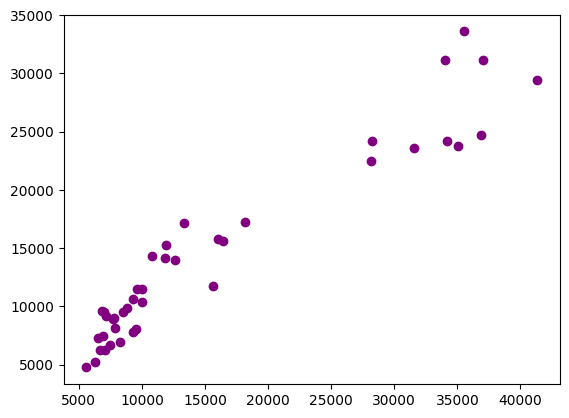

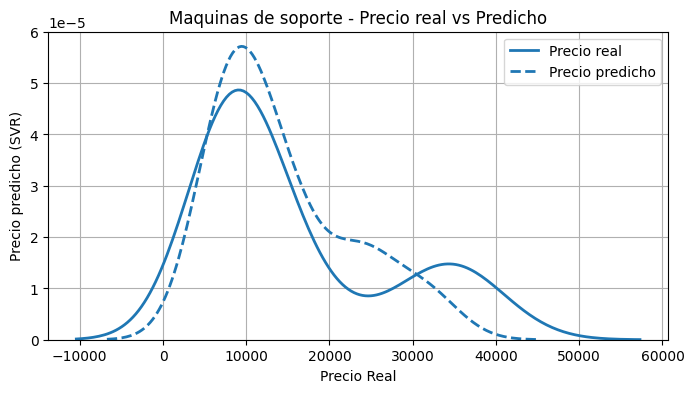

In [12]:
#COMPARAR PRECIOS REALES VS PREDICTOS
plt.scatter(y_test, y_pred, color = "purple")
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label="Precio real", linewidth=2)
sns.kdeplot(y_pred, label="Precio predicho", linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio predicho (SVR)")
plt.title("Maquinas de soporte - Precio real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

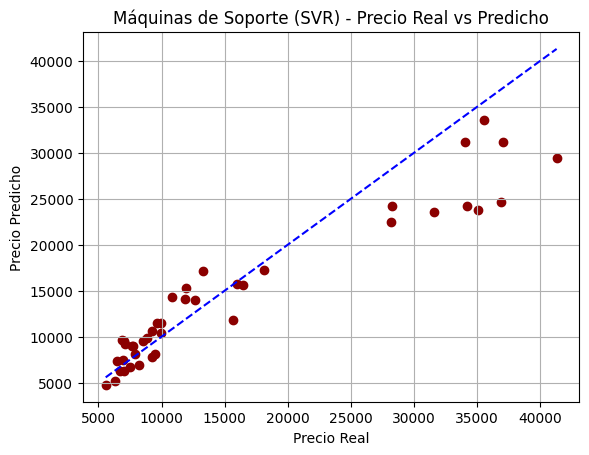

In [11]:
#COMPARAR PRECIOS CON DIAGRAMAS DE DISPERSIÓN
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Máquinas de Soporte (SVR) - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [12]:
#BUSQUEDA DE MEJORES PARAMETROS
from sklearn.model_selection import GridSearchCV

#Parametros a probar
param_grid={
    'kernel':['linear','rbf', 'poly'],
    'C':[0.1,1,10,100],
    'epsilon':[0.01, 0.1, 1],
    'gamma' : ['scale', 'auto', 0.01, 0.1, 1]
}

#Inicializacion y ajuste usando datos escalados
grid_search = GridSearchCV(SVR(), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_scaled) #Entrena con datos escalados

#Mejor modelo
best_svr = grid_search.best_estimator_
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Predecir valores con datos de prueba escalados
y_pred_scaled = best_svr.predict(X_test_scaled) # Se usa X_test_scaled

# B. Desescala las Predicciones
# La predicción (y_pred_scaled) está en la escala de Y (0 a 1).
# Debemos devolverla a la escala de precio original usando scaler_y.
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Calcular métricas (comparando predicción desescalada con y_test original)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\n Resultados del mejor modelo:")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del error cuadrático medio (RMSE): {np.sqrt(mse):.2f}")


 Mejores parámetros encontrados:
{'C': 10, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}

 Resultados del mejor modelo:
Error cuadrático medio (MSE): 23658789.30
Coeficiente de determinación (R²): 0.81
Raíz del error cuadrático medio (RMSE): 4864.03
